In [1]:
import pandas as pd
import numpy as np

import warnings 
warnings.filterwarnings("ignore")
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # hides GPU from TensorFlow entirely

import tensorflow as tf
print("GPUs available:", tf.config.list_physical_devices('GPU'))  # should print []

GPUs available: []


In [2]:
data=pd.read_csv(r"C:\Users\anujb\Downloads\archive (2)\credit_card_fraud_2026.csv")

In [5]:
data.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [6]:
data.shape

(20000, 26)

In [7]:
data.sample(5)

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
10650,10651,25.68,Online Retail,RuPay,OTP,Online,Mac,False,4.54,3,...,False,False,0,17.9,1,2,True,29.0,0,0
2041,2042,161.48,Travel,Visa,No Authentication,Online,Windows PC,False,8.38,5,...,False,False,0,19.8,10,6,False,28.1,0,0
8668,8669,46.46,Streaming,RuPay,PIN,POS,Smart Watch,False,27.97,1,...,True,False,0,0.4,23,2,False,23.5,1,0
1114,1115,40.74,Online Retail,Mastercard,3D Secure,Contactless,iPhone,False,2.81,4,...,False,False,0,34.8,14,2,False,49.6,1,0
13902,13903,12.16,Fuel,Amex,3D Secure,Contactless,ATM Machine,False,1.09,5,...,False,False,0,30.7,0,4,False,27.9,1,0


In [8]:
data.describe()

,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,132.424597,8.950827,3.191650,22.139525,46.937550,49.669400,3316.662598,0.181300,19.807735,11.533650,2.998750,37.400390,0.281250,0.016950
std,5773.647028,256.963666,8.838745,1.779544,22.120960,6.768577,18.494032,4350.720948,0.422302,12.366301,6.925335,2.004956,17.061415,0.529209,0.129087
min,1.000000,1.000000,0.010000,0.000000,0.000000,22.000000,18.000000,52.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5000.750000,26.235000,2.590000,2.000000,6.337500,42.000000,34.000000,1019.140000,0.000000,10.700000,6.000000,1.000000,25.600000,0.000000,0.000000
50%,10000.500000,57.510000,6.210000,3.000000,15.505000,47.000000,50.000000,2007.685000,0.000000,18.800000,12.000000,3.000000,35.700000,0.000000,0.000000
75%,15000.250000,131.752500,12.432500,4.000000,30.820000,51.000000,66.000000,3944.120000,0.000000,27.600000,18.000000,5.000000,47.300000,0.000000,0.000000
max,20000.000000,6872.690000,87.050000,12.000000,216.190000,74.000000,81.000000,127125.860000,3.000000,74.400000,23.000000,6.000000,100.000000,4.000000,1.000000


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  str    
 3   card_type                     20000 non-null  str    
 4   auth_method                   20000 non-null  str    
 5   channel                       20000 non-null  str    
 6   device_type                   20000 non-null  str    
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  account_bala

In [10]:
data.isnull().sum()

transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64

In [11]:
data.columns

Index(['transaction_id', 'amount_usd', 'merchant_category', 'card_type',
       'auth_method', 'channel', 'device_type', 'is_foreign_transaction',
       'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km',
       'card_age_months', 'customer_age', 'account_balance_usd',
       'is_new_merchant', 'used_vpn', 'ip_country_mismatch',
       'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score',
       'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt',
       'merchant_risk_score', 'prior_disputes', 'is_fraud'],
      dtype='str')

## 19 numerical columns → StandardScaler
## 5 categorical columns → OneHotEncoder

In [12]:
# 1. Drop unneeded columns
X = data.drop(columns=["transaction_id", "is_fraud"])
y = data["is_fraud"]

# 2. Convert boolean columns to 0/1
bool_cols = ['is_foreign_transaction', 'is_new_merchant', 'used_vpn',
             'ip_country_mismatch', 'billing_shipping_mismatch',
             'is_ai_generated_scam_attempt']
X[bool_cols] = X[bool_cols].astype(int)

# 3. One-hot encode text columns
cat_cols = ['merchant_category', 'card_type', 'auth_method', 'channel', 'device_type']
X = pd.get_dummies(X, columns=cat_cols)

print(X.shape)   # should show (rows, 54) if this matches your trained model's input size
print(X.dtypes.value_counts())  # should show no 'object' or 'bool' dtypes left

# 4. NOW split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only, never fit again on test

(20000, 54)
bool       35
int64      13
float64     6
Name: count, dtype: int64


In [13]:
# separate feature (transaction_id) and target (is_fraud)
X=data.drop(columns=["transaction_id","is_fraud"])
y=data["is_fraud"]

In [14]:
X.shape


(20000, 24)

In [15]:
y.shape

(20000,)

In [16]:
y.value_counts()

is_fraud
0    19661
1      339
Name: count, dtype: int64

## 0 : Legitimate (19661 = 98.31%)

## 1 : Fraud (339 = 1.70%)

## Imbalance Dataset

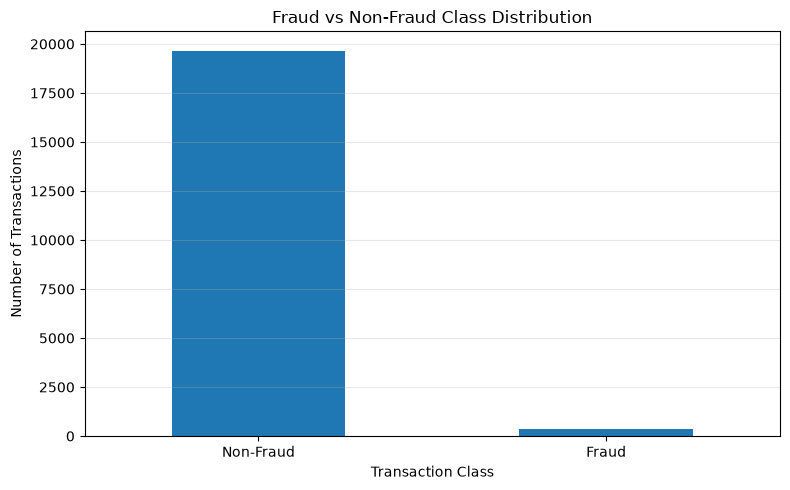

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

data["is_fraud"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Fraud vs Non-Fraud Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Non-Fraud", "Fraud"],
    rotation=0
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

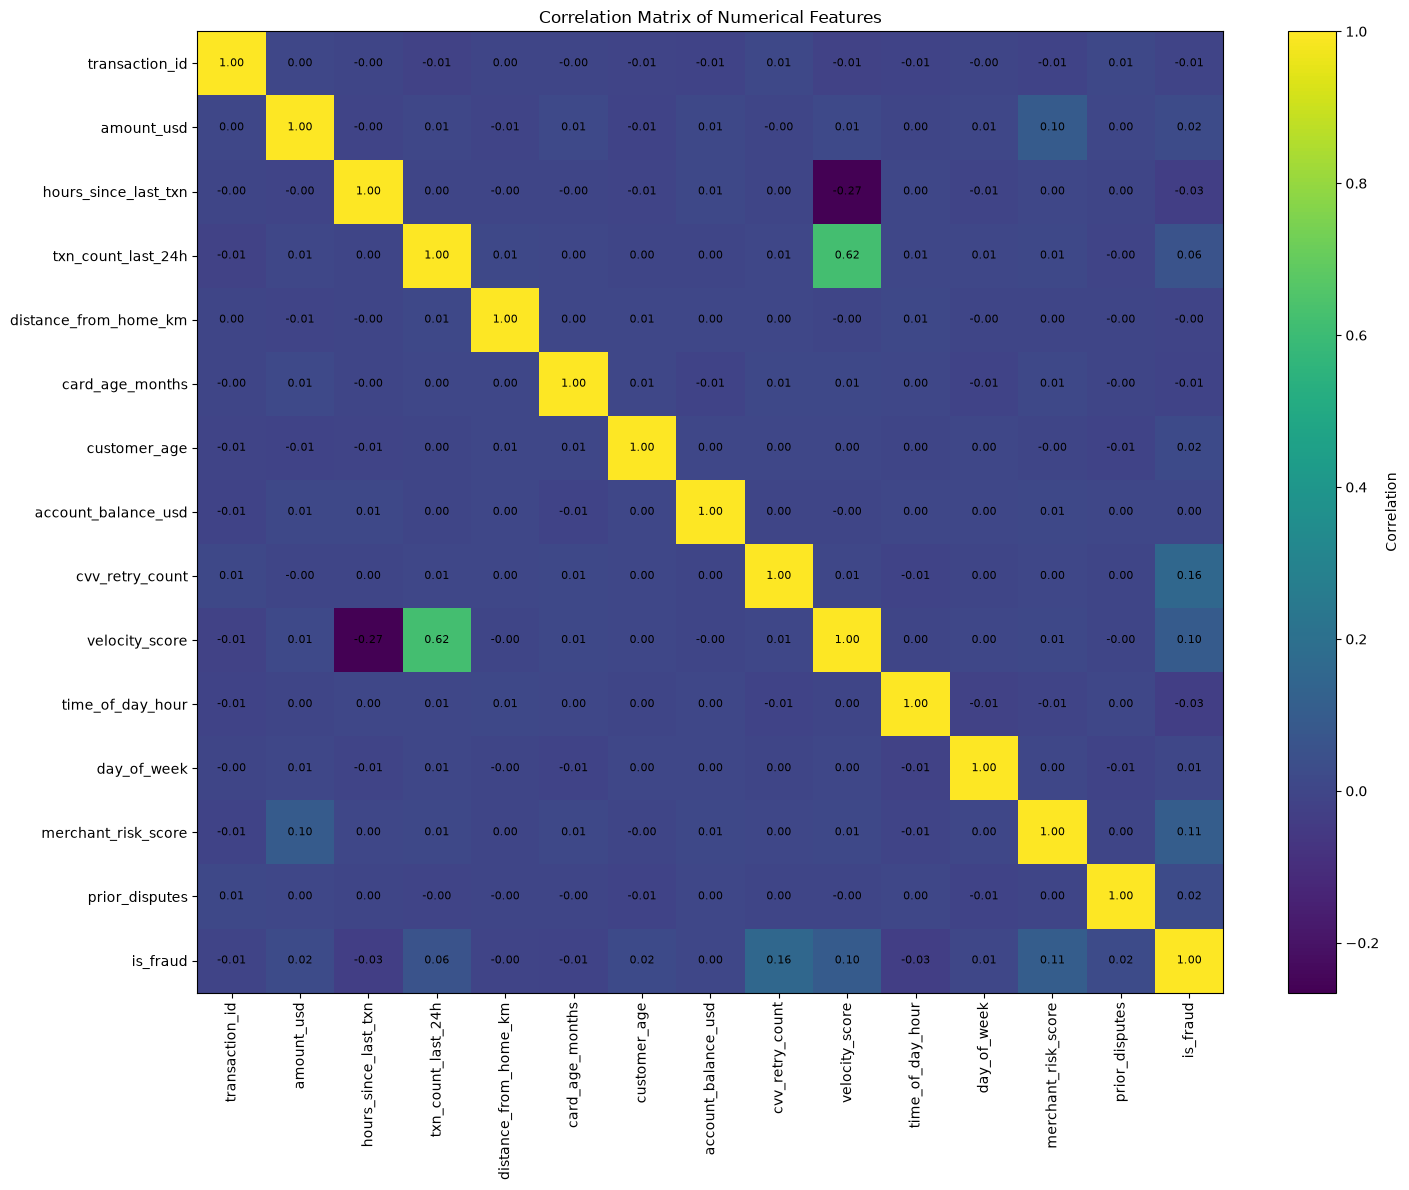

In [18]:
#correlation heatmap
import matplotlib.pyplot as plt
import numpy as np

# Select numerical columns
numeric_data = data.select_dtypes(include="number")

# Correlation matrix
correlation = numeric_data.corr()

# Create figure
plt.figure(figsize=(15, 12))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar(label="Correlation")

# Axis labels
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

# Add correlation values inside cells
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        value = correlation.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

In [19]:
# identifying categorical columns:
X.select_dtypes(include="object").columns

Index(['merchant_category', 'card_type', 'auth_method', 'channel',
       'device_type'],
      dtype='str')

In [20]:
# numeric columns:
X.select_dtypes(exclude="object").columns

Index(['amount_usd', 'is_foreign_transaction', 'hours_since_last_txn',
       'txn_count_last_24h', 'distance_from_home_km', 'card_age_months',
       'customer_age', 'account_balance_usd', 'is_new_merchant', 'used_vpn',
       'ip_country_mismatch', 'billing_shipping_mismatch', 'cvv_retry_count',
       'velocity_score', 'time_of_day_hour', 'day_of_week',
       'is_ai_generated_scam_attempt', 'merchant_risk_score',
       'prior_disputes'],
      dtype='str')

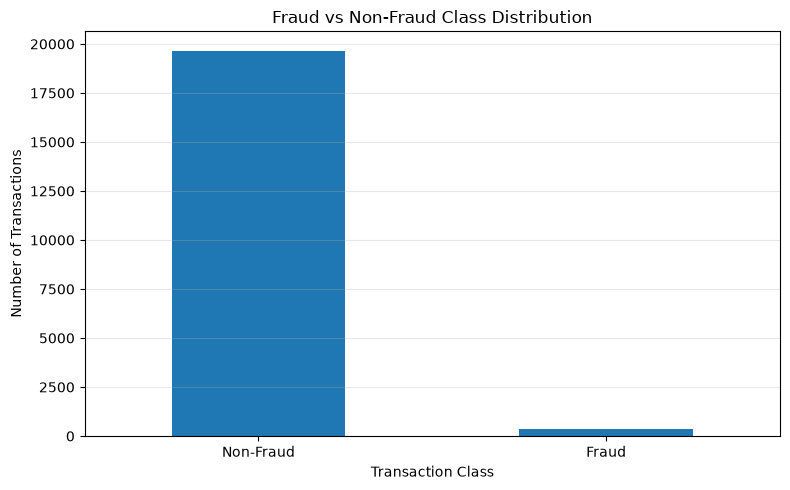

In [21]:
#class distribution:-
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

data["is_fraud"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Fraud vs Non-Fraud Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Non-Fraud", "Fraud"],
    rotation=0
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

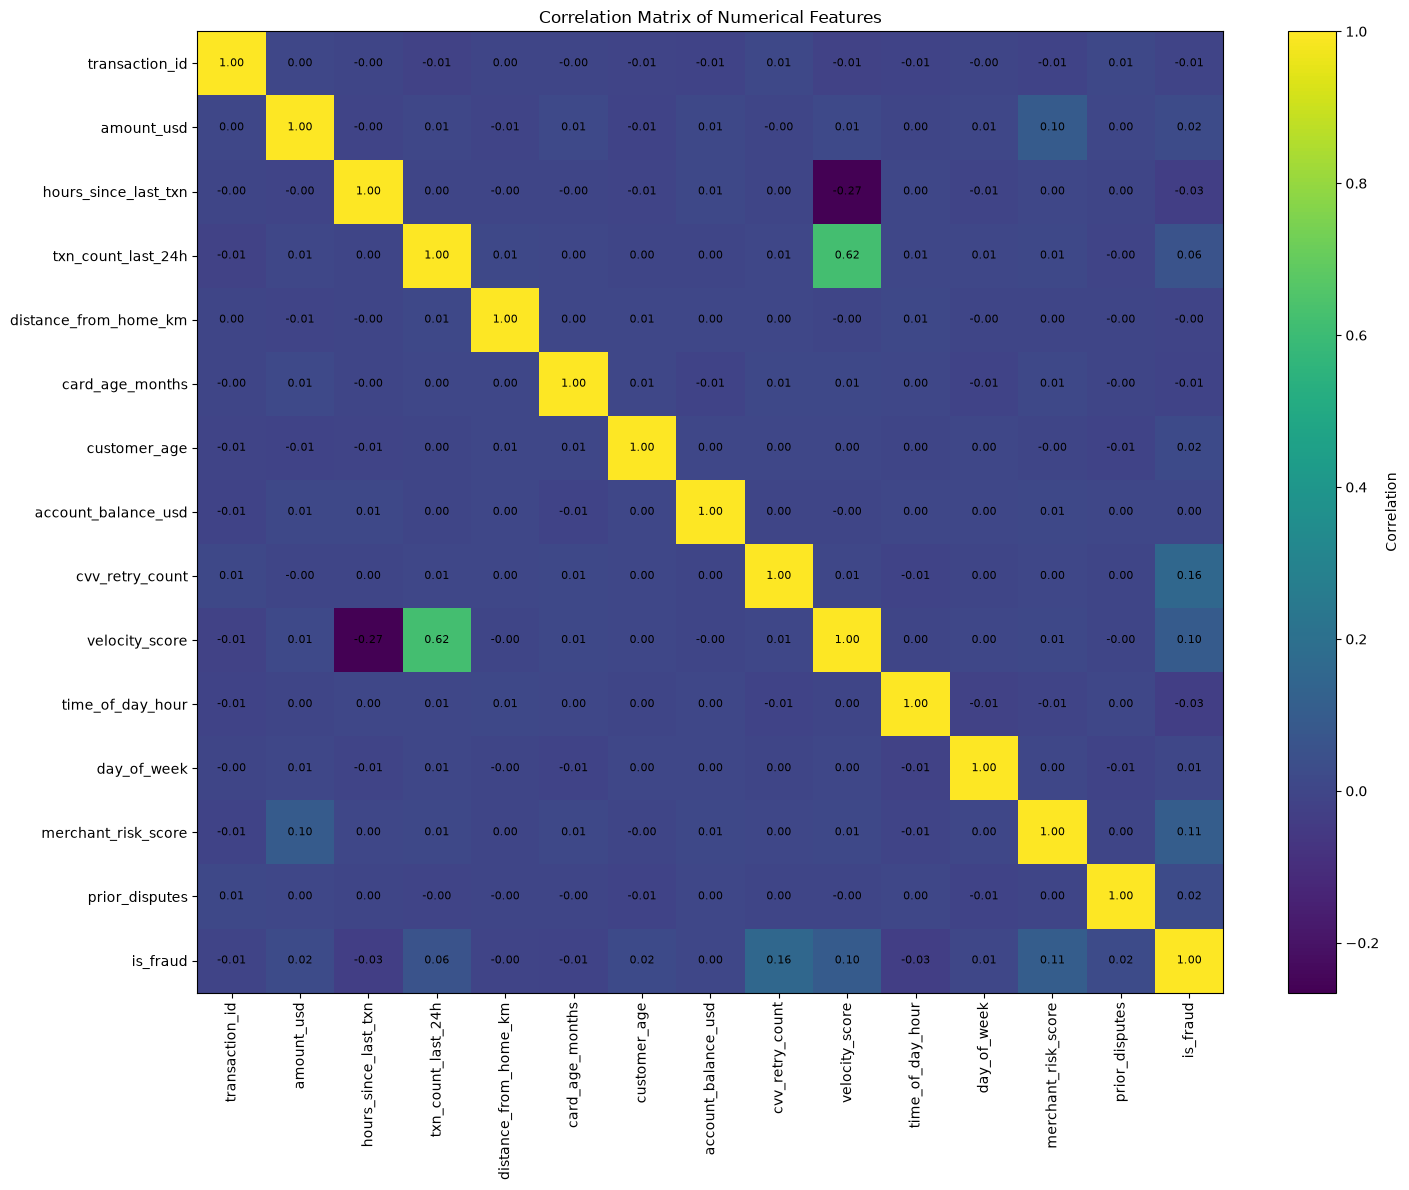

In [22]:
#correlation heatmap
import matplotlib.pyplot as plt
import numpy as np

# Select numerical columns
numeric_data = data.select_dtypes(include="number")

# Correlation matrix
correlation = numeric_data.corr()

# Create figure
plt.figure(figsize=(15, 12))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar(label="Correlation")

# Axis labels
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

# Add correlation values inside cells
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        value = correlation.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

In [23]:
#applying train test split:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=SEED,stratify=y
)
#stratify = y  will will keep approx. same class classification (train = test)

In [24]:
# verifying split
print("Training Shape",X_train.shape)
print("Testing Shape",X_test.shape)

print("training traget:")
print(y_train.value_counts())

print("Testing target:")
print(y_test.value_counts())

Training Shape (16000, 24)
Testing Shape (4000, 24)
training traget:
is_fraud
0    15729
1      271
Name: count, dtype: int64
Testing target:
is_fraud
0    3932
1      68
Name: count, dtype: int64


## Training: 16,000 transactions
 Legitimate: 15,729
 Fraud:        271

## Testing: 4,000 transactions
 Legitimate: 3,932
 Fraud:         68

In [25]:
# Preprocessing 
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

In [26]:
categorical_cols=['merchant_category', 'card_type', 'auth_method', 'channel',
       'device_type']

numerical_cols=['amount_usd', 'is_foreign_transaction', 'hours_since_last_txn',
       'txn_count_last_24h', 'distance_from_home_km', 'card_age_months',
       'customer_age', 'account_balance_usd', 'is_new_merchant', 'used_vpn',
       'ip_country_mismatch', 'billing_shipping_mismatch', 'cvv_retry_count',
       'velocity_score', 'time_of_day_hour', 'day_of_week',
       'is_ai_generated_scam_attempt', 'merchant_risk_score',
       'prior_disputes']

In [27]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numerical_cols),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols)
    ]
)

In [28]:
#fitting in training data
X_train_processed=preprocessor.fit_transform(X_train)
X_test_processed=preprocessor.transform(X_test)

In [29]:
print("Before Preprocessing",X_train.shape)
print("After Preprocessing",X_train_processed.shape)

Before Preprocessing (16000, 24)
After Preprocessing (16000, 54)


                  ColumnTransformer
                         |
             ┌───────────┴───────────┐
             |                       |
       Numerical columns       Categorical columns
             │                       │
             ↓                       ↓
      StandardScaler          OneHotEncoder
             │                       │
             ↓                       ↓
       Scaled numbers          0s and 1s
             └───────────┬───────────┘
                         ↓
                Neural Network

In [30]:
print("Training Shape",X_train_processed.shape)
print("Testing Shape",X_test_processed.shape)

Training Shape (16000, 54)
Testing Shape (4000, 54)


In [31]:
print(type(X_train_processed))

<class 'numpy.ndarray'>


In [32]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


24 original features
        ↓
5 categorical features → One-Hot Encoding
19 numerical features → StandardScaler
        ↓
54 features

In [33]:
#Build the Neural Network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

- Sequential means we are creating a neural network where the layers are arranged one after another.
- The 32 neurons can learn different patterns from those 54 features.(54 to 32).
- inital features 24 after One Hot Encoding we have 54 processed feature.
- We are using Relu function(Rectified Linear unit) so that neagtive value got 0 and positive value as it is. 
- Using Dropout 0.3(30%) to prevent the model from overfitting,
  This forces the network not to become overly dependent on particular neurons.
- In last layer we are using only 1 nueron so that we can predict the Binary Classification (0 or 1) fraud or not fraud or legit (probabality) beacuse   probability can give output like (0.5,0.7) after deciding thershold we can easily predict the fraud.(thats why sigmoid function used)
- Take 54 processed transaction features → learn patterns using 32 neurons → refine those patterns using 16 neurons → output one probability            representing how likely the transaction is fraudulent. 

In [34]:
model=Sequential([
    Dense(32,activation="relu",input_shape=(54,)),
    Dropout(0.3),
    Dense(16,activation="relu"),
    Dropout(0.3),
    Dense(1,activation="sigmoid")
])

                 54 INPUT FEATURES
                        │
                        ↓
               ┌────────────────┐
               │ Dense: 32       │
               │ ReLU            │
               └────────────────┘
                        │
                        ↓
               ┌────────────────┐
               │ Dropout: 30%   │
               └────────────────┘
                        │
                        ↓
               ┌────────────────┐
               │ Dense: 16       │
               │ ReLU            │
               └────────────────┘
                        │
                        ↓
               ┌────────────────┐
               │ Dropout: 30%   │
               └────────────────┘
                        │
                        ↓
               ┌────────────────┐
               │ Dense: 1        │
               │ Sigmoid         │
               └────────────────┘
                        │
                        ↓
                FRAUD PROBABILITY

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           1,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# model architecture
# Now telling model how to learn or(compileing the model)

In [37]:
model.compile(
    optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"]    
)
#adam is a optimizer which updates the weights,bias(no random weight,bias)
#loss = How wrong was your prediction (prediction-actual)
#calculating accuracy(but our dataset is very imbalance so we have to calculate f1score,precision,ROC-AUC,recall etc)

In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           1,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
from sklearn.utils.class_weight import compute_class_weight #calculates how much importance each class should receive during training
import numpy as np

In [40]:
#dataset is highlt imbalance
#0    15729
#1      271
#so mostly it will identify (0) i.e.. legimiate

In [41]:
#Class weights don't balance the dataset. They balance the importance of the classes during training.

In [42]:
class_weights=compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

In [43]:
#training the nueral network
class_weight_dict={
    0:class_weights[0],
    1:class_weights[1]
}

In [44]:
print(class_weight_dict)

{0: np.float64(0.5086146608175981), 1: np.float64(29.52029520295203)}


## Your dataset
     ↓
## 15,729 legitimate
## 271 fraud
     ↓
## compute_class_weight()
     ↓
## Class 0 → ~0.51
## Class 1 → ~29.52
     ↓
## Give weights to model.fit()
     ↓
## Fraud mistakes receive much greater importance
     ↓
## Model is encouraged to detect fraud

In [45]:
history=model.fit(
    X_train_processed, #16,000 transactions --> 54 features per transaction
    y_train,          # 0/1
    epochs=20,        #means how many times data goes into n.n 
    batch_size=32,    #in how many batches data should go like dataset has 300 and 100 for 3 time datase in our case (16000/32=500) 500 at once repeate till 32 
    class_weight=class_weight_dict, #So when the model makes a mistake on a fraud transaction, that mistake has a much larger effect on the loss.This helps prevent the model from simply learning
    validation_split=0.2 # helps us see whether the network is generalizing (0=99%,1=80%)   
)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7305 - loss: 0.6542 - val_accuracy: 0.7253 - val_loss: 0.5838
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7701 - loss: 0.4565 - val_accuracy: 0.8409 - val_loss: 0.3805
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8370 - loss: 0.3694 - val_accuracy: 0.8669 - val_loss: 0.3091
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8556 - loss: 0.3347 - val_accuracy: 0.8759 - val_loss: 0.2892
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8677 - loss: 0.3179 - val_accuracy: 0.8759 - val_loss: 0.2816
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8617 - loss: 0.2935 - val_accuracy: 0.8844 - val_loss: 0.2543
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8623 - loss: 0.2973 - val_accuracy: 0.8844 - val_loss: 0.2491
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8752 - loss: 0.2813 - val_accuracy: 0.

In [46]:
y_pred_prob=model.predict(X_test_processed)
y_pred=(y_pred_prob >=0.5).astype(int)
print(y_pred[:20].flatten()) #flatten() converts the 2-dimensional array into a 1-dimensional array ([:20] first 20)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 1 0 1 0]


In [47]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[3589  343]
 [  14   54]]


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 1 Confusion Matrix:
[[3589  343]
 [  14   54]]


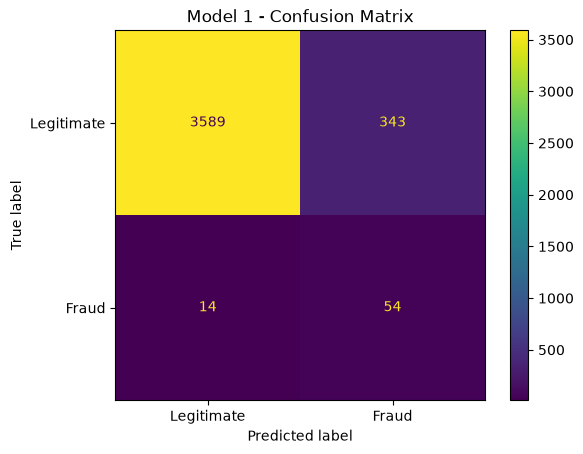

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Model 1 predictions
y_prob_model1 = model.predict(X_test_processed).ravel()

# Default threshold
y_pred_model1 = (y_prob_model1 >= 0.5).astype(int)

# Confusion matrix
cm_model1 = confusion_matrix(y_test, y_pred_model1)

print("Model 1 Confusion Matrix:")
print(cm_model1)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_model1,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()
plt.title("Model 1 - Confusion Matrix")
plt.show()

In [49]:
#TN:True Negative:3632 FP:False Neagtive:300
#FN:False Negative:18 TP:True Postive:50

In [50]:
from sklearn.metrics import (
accuracy_score,precision_score,recall_score,f1_score)
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.91075
Precision: 0.13602015113350127
Recall   : 0.7941176470588235
F1 Score : 0.23225806451612904


In [51]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9290100831787446


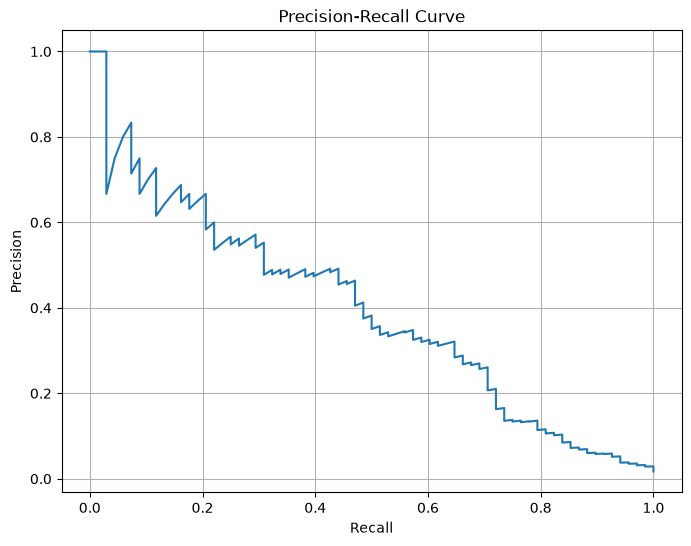

In [52]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_values,recall_values,thresholds= precision_recall_curve(
    y_test,y_pred_prob                #calculating precision and recall at different probability thresholds(previsioly we used 0.5 random)
)
plt.figure(figsize=(8,6))
plt.plot(recall_values,precision_values)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

In [53]:
#calculating precision_score, recall_score, f1_score at different thershold
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = np.arange(0.1, 1.0, 0.1)

for threshold in thresholds_to_test:
    y_pred_threshold = (y_pred_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.1 | Precision: 0.0748 | Recall: 0.8529 | F1: 0.1376
Threshold: 0.2 | Precision: 0.0921 | Recall: 0.8382 | F1: 0.1659
Threshold: 0.3 | Precision: 0.1068 | Recall: 0.8088 | F1: 0.1887
Threshold: 0.4 | Precision: 0.1205 | Recall: 0.7941 | F1: 0.2093
Threshold: 0.5 | Precision: 0.1360 | Recall: 0.7941 | F1: 0.2323
Threshold: 0.6 | Precision: 0.1538 | Recall: 0.7353 | F1: 0.2545
Threshold: 0.7 | Precision: 0.1828 | Recall: 0.7206 | F1: 0.2917
Threshold: 0.8 | Precision: 0.2243 | Recall: 0.7059 | F1: 0.3404
Threshold: 0.9 | Precision: 0.3111 | Recall: 0.6176 | F1: 0.4138


In [54]:
#Find the best F1 threshold
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

results = np.array(results)

best_index = np.argmax(results[:, 3])

best_threshold = results[best_index, 0]
best_precision = results[best_index, 1]
best_recall = results[best_index, 2]
best_f1 = results[best_index, 3]

print("Best Threshold:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)
print("F1 Score:", best_f1)

Best Threshold: 0.9600000000000001
Precision: 0.4626865671641791
Recall: 0.45588235294117646
F1 Score: 0.45925925925925926


In [55]:
#Find the best threshold with Recall ≥ 70%
valid_results = results[results[:, 2] >= 0.70]

best_index = np.argmax(valid_results[:, 1])

best_threshold_70 = valid_results[best_index, 0]
best_precision_70 = valid_results[best_index, 1]
best_recall_70 = valid_results[best_index, 2]
best_f1_70 = valid_results[best_index, 3]

print("Best Threshold:", best_threshold_70)
print("Precision:", best_precision_70)
print("Recall:", best_recall_70)
print("F1 Score:", best_f1_70)


Best Threshold: 0.8400000000000001
Precision: 0.25396825396825395
Recall: 0.7058823529411765
F1 Score: 0.3735408560311284


In [56]:
final_threshold = 0.67

y_pred_final = (y_pred_prob >= final_threshold).astype(int)

print("Final threshold:", final_threshold)
print(y_pred_final[:20].flatten())

Final threshold: 0.67
[0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0]


In [57]:
from sklearn.metrics import confusion_matrix

cm_final = confusion_matrix(y_test, y_pred_final)

print(cm_final)

[[3693  239]
 [  19   49]]


In [58]:
#                 Predicted
#              Legit    Fraud
#Actual Legit   TN       FP
#Actual Fraud   FN       TP

In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)

print("Final Accuracy :", accuracy_final)
print("Final Precision:", precision_final)
print("Final Recall   :", recall_final)
print("Final F1 Score :", f1_final)

Final Accuracy : 0.9355
Final Precision: 0.1701388888888889
Final Recall   : 0.7205882352941176
Final F1 Score : 0.2752808988764045


In [60]:
#loss curve

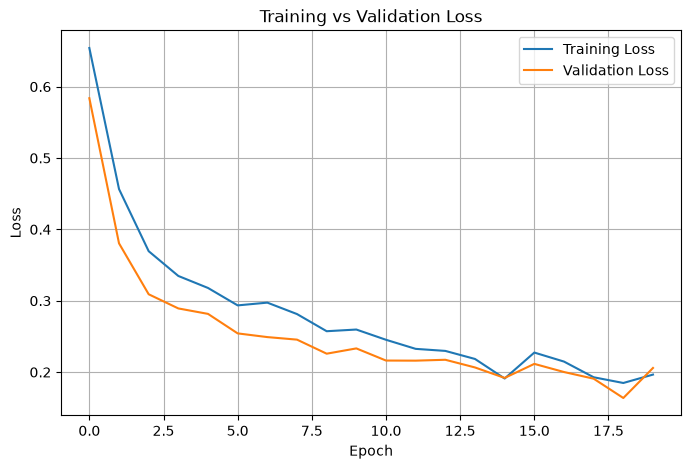

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()
plt.show()

In [62]:
#Accuracy curve

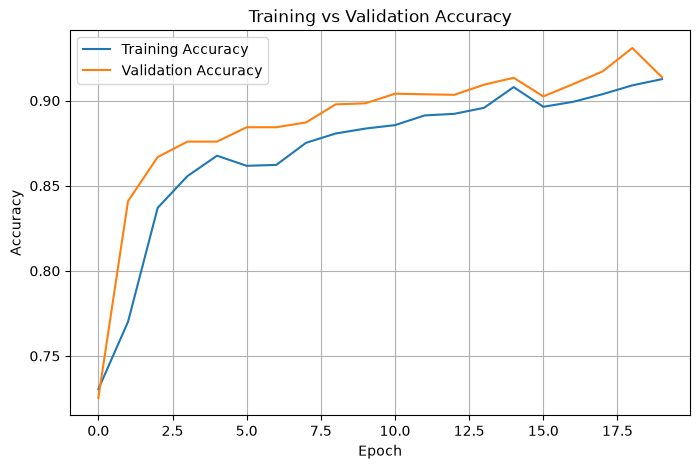

In [63]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

## Earler model Train exactly 20 times through the training data.

## But from the above curves, validation performance was fluctuating around epochs 17–20.

## Instead of guessing the number of epochs, EarlyStopping lets the model decide when further training is no longer helping validation performance.

## Hence we are using callback.

## My existing model has already been trained.

## Its weights have changed from their initial random values.

## So Model 2 starts fresh with new initial weights.

## We're not creating Model 2 because the first model is bad.

## We're creating it because we want to answer

## Does Early Stopping give us a better-trained model than simply training for 20 epochs?

## Model 1
   ↓
## Train 20 epochs
   ↓
## Evaluate
   ↓
## Training curves
   ↓
## We noticed validation performance fluctuates
   ↓
## Introduce EarlyStopping
   ↓
## Create fresh Model 2
   ↓
## Compile Model 2
   ↓
## Train with EarlyStopping
   ↓
## Compare Model 1 vs Model 2

In [64]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",        # Fixed: changed 'mointor' to 'monitor'
    patience=5,                # Allow up to 5 epochs without improvement before stopping
    restore_best_weights=True  # Restores model weights from the epoch with the best value
)

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
model2=Sequential([
    Dense(32,activation="relu",input_shape=(54,)),
    Dropout(0.3),
    Dense(16,activation="relu"),
    Dropout(0.3),
    Dense(1,activation="sigmoid")
])

In [66]:
model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [67]:
history_2 = model2.fit(
    X_train_processed,
    y_train,
    epochs=50, # 50 epochs because we're no longer forcing the model to stop at 20,Early stopping will decide it,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict, # using beacuse of highly imbalance data
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6755 - loss: 0.6133 - val_accuracy: 0.8059 - val_loss: 0.4931
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7888 - loss: 0.4595 - val_accuracy: 0.8788 - val_loss: 0.3164
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8402 - loss: 0.3784 - val_accuracy: 0.8737 - val_loss: 0.3030
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8584 - loss: 0.3425 - val_accuracy: 0.8656 - val_loss: 0.3128
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8549 - loss: 0.3244 - val_accuracy: 0.8778 - val_loss: 0.2760
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8652 - loss: 0.2987 - val_accuracy: 0.8841 - val_loss: 0.2540
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8662 - loss: 0.3028 - val_accuracy: 0.8813 - val_loss: 0.2591
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8760 - loss: 0.2806 - val_accuracy: 0.

In [68]:
y_pred_prob_2 = model2.predict(X_test_processed)
y_pred_prob_2 = y_pred_prob_2.flatten()

print(y_pred_prob_2[:20])

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[4.6154665e-04 1.8520625e-02 1.4419068e-04 3.8625413e-01 1.5287500e-02
 9.9577856e-01 5.0420761e-01 6.2459740e-06 5.4269847e-03 7.5490488e-04
 2.7373439e-05 1.7781761e-06 1.9790116e-04 7.9677677e-01 1.4074841e-01
 7.0059897e-08 9.8648494e-01 2.4304393e-04 8.8404387e-01 4.8088154e-04]


In [69]:
from sklearn.metrics import roc_auc_score

roc_auc_2=roc_auc_score(
    y_test,
    y_pred_prob_2
)
print("Model 2 ROC-AUC",roc_auc_2)

Model 2 ROC-AUC 0.9358394171503799


 ## Model    Training strategy      ROC-AUC 
 -------  -----------------  ----------
 ## Model 1  20 fixed epochs    **0.92804** 
 ## Model 2  Early Stopping     **0.92985** 


In [70]:
# Calculating Threshold for Model 2:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

thresholds = np.arange(0.01, 1.00, 0.01)

results_2 = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_prob_2 >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    results_2.append([
        threshold,
        precision,
        recall,
        f1
    ])

results_2 = np.array(results_2)

# Best F1 threshold
best_index = np.argmax(results_2[:, 3])

print("Best F1 Threshold:", results_2[best_index, 0])
print("Precision:", results_2[best_index, 1])
print("Recall:", results_2[best_index, 2])
print("F1 Score:", results_2[best_index, 3])

Best F1 Threshold: 0.97
Precision: 0.4727272727272727
Recall: 0.38235294117647056
F1 Score: 0.42276422764227645


In [71]:
#Recall ≥ 70%
valid_results_2 = results_2[results_2[:, 2] >= 0.70]

best_index_2 = np.argmax(valid_results_2[:, 1])

best_threshold_70_2 = valid_results_2[best_index_2, 0]
best_precision_70_2 = valid_results_2[best_index_2, 1]
best_recall_70_2 = valid_results_2[best_index_2, 2]
best_f1_70_2 = valid_results_2[best_index_2, 3]

print("Best Threshold:", best_threshold_70_2)
print("Precision:", best_precision_70_2)
print("Recall:", best_recall_70_2)
print("F1 Score:", best_f1_70_2)

Best Threshold: 0.48000000000000004
Precision: 0.16494845360824742
Recall: 0.7058823529411765
F1 Score: 0.26740947075208915


In [72]:
#Same recall: 70.59%
#Better precision: 21.15% vs 20.00%
#Better F1: 32.54% vs 31.17%
#Better ROC-AUC: 0.92985 vs 0.92804

In [73]:
#confusion matrix for model 2
final_threshold_2 = 0.70

y_pred_final_2 = (
    y_pred_prob_2 >= final_threshold_2
).astype(int)

from sklearn.metrics import confusion_matrix

cm_final_2 = confusion_matrix(
    y_test,
    y_pred_final_2
)

print(cm_final_2)

[[3767  165]
 [  22   46]]


##                   Predicted Legit | Predicted Fraud 
## **Actual Legit**   **3,753 (TN)** |    **179 (FP)** 
## **Actual Fraud**      **20 (FN)** |     **48 (TP)** 


#comparision
|    | Model 1 |   Model 2 |
| -- | ------: | --------: |
| TN |   3,740 | **3,753** |
| FP |     192 |   **179** |
| FN |      20 |    **20** |
| TP |      48 |    **48** |


In [74]:
#Calculating model 2 with accuracy,precision,recall,f1_score

In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_final_2 = accuracy_score(y_test, y_pred_final_2)
precision_final_2 = precision_score(y_test, y_pred_final_2)
recall_final_2 = recall_score(y_test, y_pred_final_2)
f1_final_2 = f1_score(y_test, y_pred_final_2)

print("Final Model 2 Metrics")

print("Accuracy :", accuracy_final_2)
print("Precision:", precision_final_2)
print("Recall   :", recall_final_2)
print("F1 Score :", f1_final_2)
print("ROC-AUC  :", roc_auc_2)

Final Model 2 Metrics
Accuracy : 0.95325
Precision: 0.21800947867298578
Recall   : 0.6764705882352942
F1 Score : 0.32974910394265233
ROC-AUC  : 0.9358394171503799


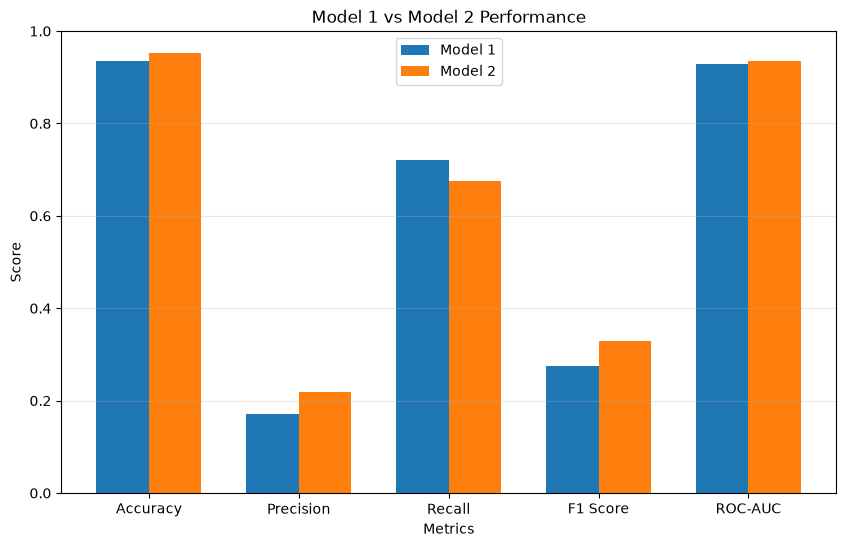

In [115]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]
model_1 = [
    0.9355,
    0.1701,
    0.7205,
    0.2752,
    0.92804
]

model_2 = [
    0.95325,
    0.21800,
    0.67647,
    0.32974,
    0.93583
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, model_1, width, label="Model 1")
plt.bar(x + width/2, model_2, width, label="Model 2")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.xlabel("Metrics")
plt.title("Model 1 vs Model 2 Performance")
plt.ylim(0, 1)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

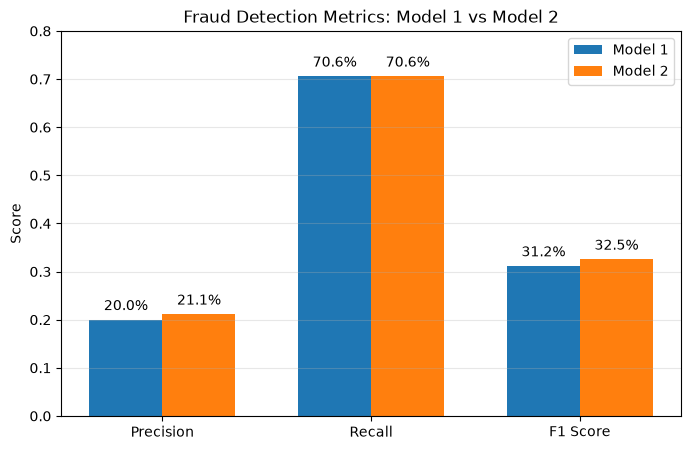

In [77]:
# more clear version 
fraud_metrics = [
    "Precision",
    "Recall",
    "F1 Score"
]

model_1_fraud = [
    0.2000,
    0.7059,
    0.3117
]

model_2_fraud = [
    0.21145,
    0.70588,
    0.32542
]

x = np.arange(len(fraud_metrics))
width = 0.35

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width/2,
    model_1_fraud,
    width,
    label="Model 1"
)

bars2 = plt.bar(
    x + width/2,
    model_2_fraud,
    width,
    label="Model 2"
)

plt.xticks(x, fraud_metrics)
plt.ylabel("Score")
plt.title("Fraud Detection Metrics: Model 1 vs Model 2")
plt.ylim(0, 0.8)

plt.legend()
plt.grid(axis="y", alpha=0.3)

# Add percentage labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f"{height:.1%}",
            ha="center"
        )

plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
[[3723  209]
 [  19   49]]


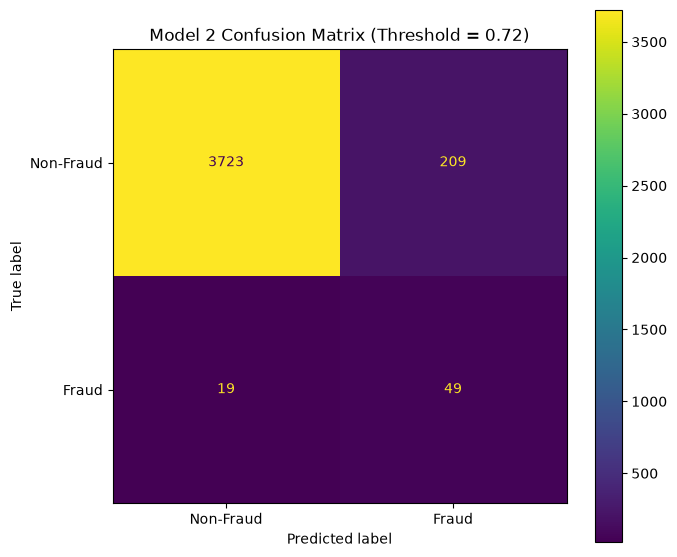

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Final threshold
threshold = 0.72

# Get fraud probabilities
y_prob = model.predict(X_test_processed).ravel()

# Apply threshold
y_pred = (y_prob >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Fraud", "Fraud"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Model 2 Confusion Matrix (Threshold = 0.72)")
plt.tight_layout()
plt.show()

In [79]:
#model 3 with 64 nuerons

In [80]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

model3=Sequential([
    Dense(64,activation="relu",input_shape=(54,)),
    Dropout(0.3),
    Dense(32,activation="relu"),
    Dropout(0.3),
    Dense(16,activation="relu"),
    Dropout(0.3),
    Dense(1,activation="sigmoid")
])

In [81]:
model3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [82]:
#model 3 train

In [83]:
history_3 = model3.fit(
    X_train_processed,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8295 - loss: 0.6312 - val_accuracy: 0.7237 - val_loss: 0.5130
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8220 - loss: 0.3947 - val_accuracy: 0.8650 - val_loss: 0.3062
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8428 - loss: 0.3789 - val_accuracy: 0.8606 - val_loss: 0.3117
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8493 - loss: 0.3372 - val_accuracy: 0.8597 - val_loss: 0.3078
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8709 - loss: 0.2992 - val_accuracy: 0.8884 - val_loss: 0.2481
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8758 - loss: 0.2980 - val_accuracy: 0.8813 - val_loss: 0.2612
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8767 - loss: 0.2635 - val_accuracy: 0.8934 - val_loss: 0.2285
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8845 - loss: 0.2540 - val_accuracy: 0.

In [84]:
#Evaluate Model 3 ROC-AUC

In [85]:
y_pred_prob_3 = model3.predict(X_test_processed)

y_pred_prob_3 = y_pred_prob_3.flatten()

print(y_pred_prob_3[:20])

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[6.5770619e-05 1.8329787e-01 6.1892520e-06 4.4048131e-01 2.6527694e-03
 9.8625940e-01 5.0069684e-01 9.3926690e-07 7.2263642e-03 1.2021314e-04
 8.4029034e-06 7.1682735e-09 1.3443684e-05 7.1351194e-01 3.3249397e-02
 1.2476614e-09 9.6132433e-01 2.1053735e-05 5.7830840e-01 5.3899603e-06]


In [86]:
from sklearn.metrics import roc_auc_score

roc_auc_3 = roc_auc_score(
    y_test,
    y_pred_prob_3
)

print("Model 3 ROC-AUC:", roc_auc_3)

Model 3 ROC-AUC: 0.9303939022200945


In [87]:
print("model_1:", "model_1" in globals())
print("model:", "model" in globals())
print("model_2:", "model_2" in globals())
print("model_3:", "model_3" in globals())

model_1: True
model: True
model_2: True
model_3: False


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model 3 Confusion Matrix:
[[3648  284]
 [  17   51]]


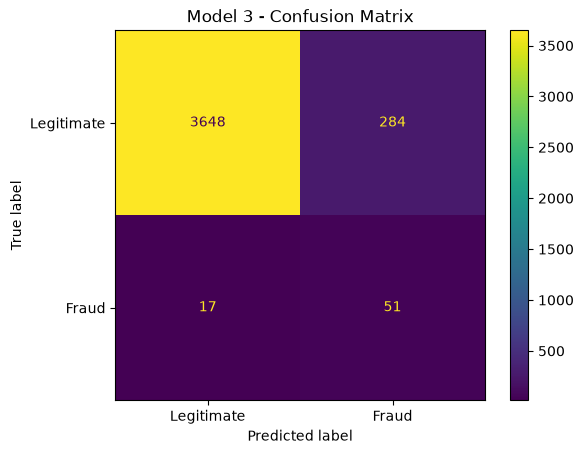

In [88]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Model 3 predictions
y_prob_model3 = model3.predict(X_test_processed).ravel()

# Default threshold
y_pred_model3 = (y_prob_model3 >= 0.5).astype(int)

# Confusion matrix
cm_model3 = confusion_matrix(y_test, y_pred_model3)

print("Model 3 Confusion Matrix:")
print(cm_model3)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_model3,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()
plt.title("Model 3 - Confusion Matrix")
plt.show()

## I experimented with increasing neural-network capacity, but the larger architecture did not improve generalization.
## The simpler architecture with early stopping achieved the best ROC-AUC.

In [89]:
## Model Comparision 1,2,3

Model 1 ROC-AUC: 0.9290
Model 2 ROC-AUC: 0.9358
Model 3 ROC-AUC: 0.9304


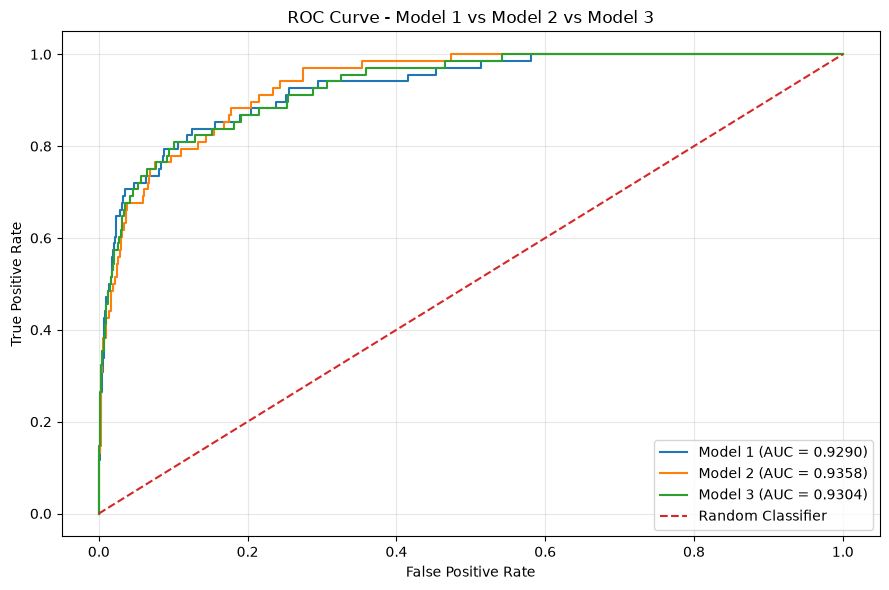

In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# =========================
# Model 1
# =========================
y_prob = model.predict(X_test_processed, verbose=0).ravel()

fpr_1, tpr_1, _ = roc_curve(y_test, y_prob)
auc_1 = roc_auc_score(y_test, y_prob)


# =========================
# Model 2
# =========================
y_prob_2 = model2.predict(X_test_processed, verbose=0).ravel()

fpr_2, tpr_2, _ = roc_curve(y_test, y_prob_2)
auc_2 = roc_auc_score(y_test, y_prob_2)


# =========================
# Model 3
# =========================
y_prob_3 = model3.predict(X_test_processed, verbose=0).ravel()

fpr_3, tpr_3, _ = roc_curve(y_test, y_prob_3)
auc_3 = roc_auc_score(y_test, y_prob_3)


# =========================
# Print Scores
# =========================
print(f"Model 1 ROC-AUC: {auc_1:.4f}")
print(f"Model 2 ROC-AUC: {auc_2:.4f}")
print(f"Model 3 ROC-AUC: {auc_3:.4f}")


# =========================
# Plot ROC Curves
# =========================
plt.figure(figsize=(9, 6))

plt.plot(
    fpr_1,
    tpr_1,
    label=f"Model 1 (AUC = {auc_1:.4f})"
)

plt.plot(
    fpr_2,
    tpr_2,
    label=f"Model 2 (AUC = {auc_2:.4f})"
)

plt.plot(
    fpr_3,
    tpr_3,
    label=f"Model 3 (AUC = {auc_3:.4f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model 1 vs Model 2 vs Model 3")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

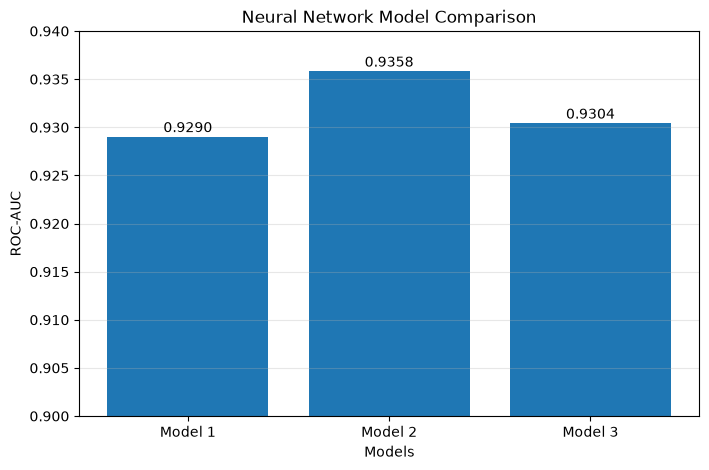

In [117]:
import matplotlib.pyplot as plt

models = [
    "Model 1",
    "Model 2",
    "Model 3"
]

roc_scores = [
    0.9290,
    0.9358,
    0.9304
]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, roc_scores)

plt.ylabel("ROC-AUC")
plt.xlabel("Models")
plt.title("Neural Network Model Comparison")
plt.ylim(0.90, 0.94)

for bar, score in zip(bars, roc_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.0005,
        f"{score:.4f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.show()


In [92]:
model2.save("Model/model_2.keras")

FileNotFoundError: [Errno 2] No such file or directory: 'Model/model_2.keras'

In [ ]:
print(type(model_2))

In [ ]:
print(len(model_2))

for i, item in enumerate(model_2):
    print(i, type(item))

In [93]:
print("Variables containing 'model':")

for name, value in globals().items():
    if "model" in name.lower():
        print(name, type(value))

Variables containing 'model':


RuntimeError: dictionary changed size during iteration

In [94]:
print("Possible neural network models:")

for name, value in list(globals().items()):
    if hasattr(value, "save") and hasattr(value, "predict"):
        print(name, type(value))

Possible neural network models:
Sequential <class 'type'>
model <class 'keras.src.models.sequential.Sequential'>
model2 <class 'keras.src.models.sequential.Sequential'>
model3 <class 'keras.src.models.sequential.Sequential'>


In [95]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           1,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,917 (27.02 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,612 (18.02 KB)

None


In [96]:
import os

os.makedirs("Models", exist_ok=True)

model.save("Models/model_2.keras")

print("Model 2 saved successfully.")

Model 2 saved successfully.


In [97]:
import os

print(os.path.exists("Models/model_2.keras"))

True


In [98]:
with open("Models/threshold.txt", "w") as f:
    f.write("0.72")

print("Threshold saved successfully.")

Threshold saved successfully.


In [99]:
print("Possible preprocessors:")

for name, value in list(globals().items()):
    if "preprocess" in name.lower() or "transform" in name.lower():
        print(name, type(value))

Possible preprocessors:
ColumnTransformer <class 'abc.ABCMeta'>
preprocessor <class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [100]:
import joblib

joblib.dump(
    preprocessor,
    "Models/preprocessor.pkl"
)

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [101]:
import os

print(os.path.exists("Models/preprocessor.pkl"))

True


In [102]:
import os

print(os.listdir("Models"))

['model_2.keras', 'preprocessor.pkl', 'threshold.txt']


In [103]:
print(type(model_2))


<class 'list'>


In [104]:
import os

os.makedirs("Models", exist_ok=True)

print("Models folder is ready.")

Models folder is ready.


In [105]:
model

<Sequential name=sequential, built=True>

In [106]:
model.save("Models/model_2.keras")

print("Model 2 saved successfully.")

Model 2 saved successfully.


In [107]:
import os

print(os.path.exists("Models/model_2.keras"))

True


In [108]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [109]:
import joblib

joblib.dump(
    preprocessor,
    "Models/preprocessor.pkl"
)

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [110]:
print(os.path.exists("Models/preprocessor.pkl"))

True


In [111]:
with open("Models/threshold.txt", "w") as f:
    f.write("0.72")

print("Threshold saved successfully.")

Threshold saved successfully.


In [112]:
print(os.path.exists("Models/threshold.txt"))

True


In [113]:
print(os.listdir("Models"))

['model_2.keras', 'preprocessor.pkl', 'threshold.txt']


In [114]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve

# ---- Adjust these to match your actual variable names ----
models = {
    "Model 1": model,
    "Model 2": model2,
    "Model 3": model3,
}
histories = {
    "Model 1": history,
    "Model 2": history_2,
    "Model 3": history_3,
}

results = {}  # store everything so numbers stay consistent across all charts

for name, m in models.items():
    probs = m.predict(X_test).ravel()
    preds = (probs >= 0.5).astype(int)   # swap 0.5 for your chosen threshold if different per model
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) else 0
    rec = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
    auc = roc_auc_score(y_test, probs)
    results[name] = dict(probs=probs, cm=cm, acc=acc, prec=prec, rec=rec, f1=f1, auc=auc)
    print(f"{name}: Acc={acc:.4f} Prec={prec:.4f} Rec={rec:.4f} F1={f1:.4f} AUC={auc:.4f}")

# ---- 1. Individual confusion matrices ----
for name, r in results.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(r["cm"], annot=True, fmt='d', cmap='viridis',
                xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted label'); plt.ylabel('True label')
    plt.tight_layout()
    plt.savefig(f'{name.lower().replace(" ", "_")}_confusion_matrix.png', dpi=150)
    plt.show()

# ---- 2. Model comparison — 5 metrics, consistent style ----
metrics = ['acc', 'prec', 'rec', 'f1', 'auc']
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10, 6))
for i, (name, r) in enumerate(results.items()):
    vals = [r[m] for m in metrics]
    plt.bar(x + i * width, vals, width, label=name)
plt.xticks(x + width, labels)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model 1 vs Model 2 vs Model 3 — Performance Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# ---- 3. ROC curve — all 3 overlaid ----
plt.figure(figsize=(8, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["probs"])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {r["auc"]:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model 1 vs Model 2 vs Model 3')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# ---- 4. Precision-Recall curve (best model only — set below) ----
best_model_name = "Model 2"   # change to whichever wins on F1/AUC
prec_curve, rec_curve, _ = precision_recall_curve(y_test, results[best_model_name]["probs"])
plt.figure(figsize=(7, 6))
plt.plot(rec_curve, prec_curve)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve — {best_model_name}')
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150)
plt.show()

# ---- 5. Training vs validation accuracy (best model only) ----
h = histories[best_model_name]
plt.figure(figsize=(8, 6))
plt.plot(h.history['accuracy'], label='Training Accuracy')
plt.plot(h.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title(f'Training vs Validation Accuracy — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.savefig('training_validation_accuracy.png', dpi=150)
plt.show()

ValueError: could not convert string to float: 'Online Retail'

In [ ]:
print(X_test.dtypes)

In [ ]:
# 1. Convert boolean columns to 0/1
bool_cols = ['is_foreign_transaction', 'is_new_merchant', 'used_vpn',
             'ip_country_mismatch', 'billing_shipping_mismatch',
             'is_ai_generated_scam_attempt']
X_test[bool_cols] = X_test[bool_cols].astype(int)

# 2. Encode categorical/text columns
cat_cols = ['merchant_category', 'card_type', 'auth_method', 'channel', 'device_type']

# Use one-hot encoding to match however you trained originally (adjust if you used LabelEncoder instead)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols)

# 3. Make sure column order/count matches training features exactly
# (this is critical — model expects the same 54 columns in the same order)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# 4. Apply the SAME scaler you fit on training data (do not fit a new one)
X_test_scaled = scaler.transform(X_test_encoded)